# **Lecture 1**

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

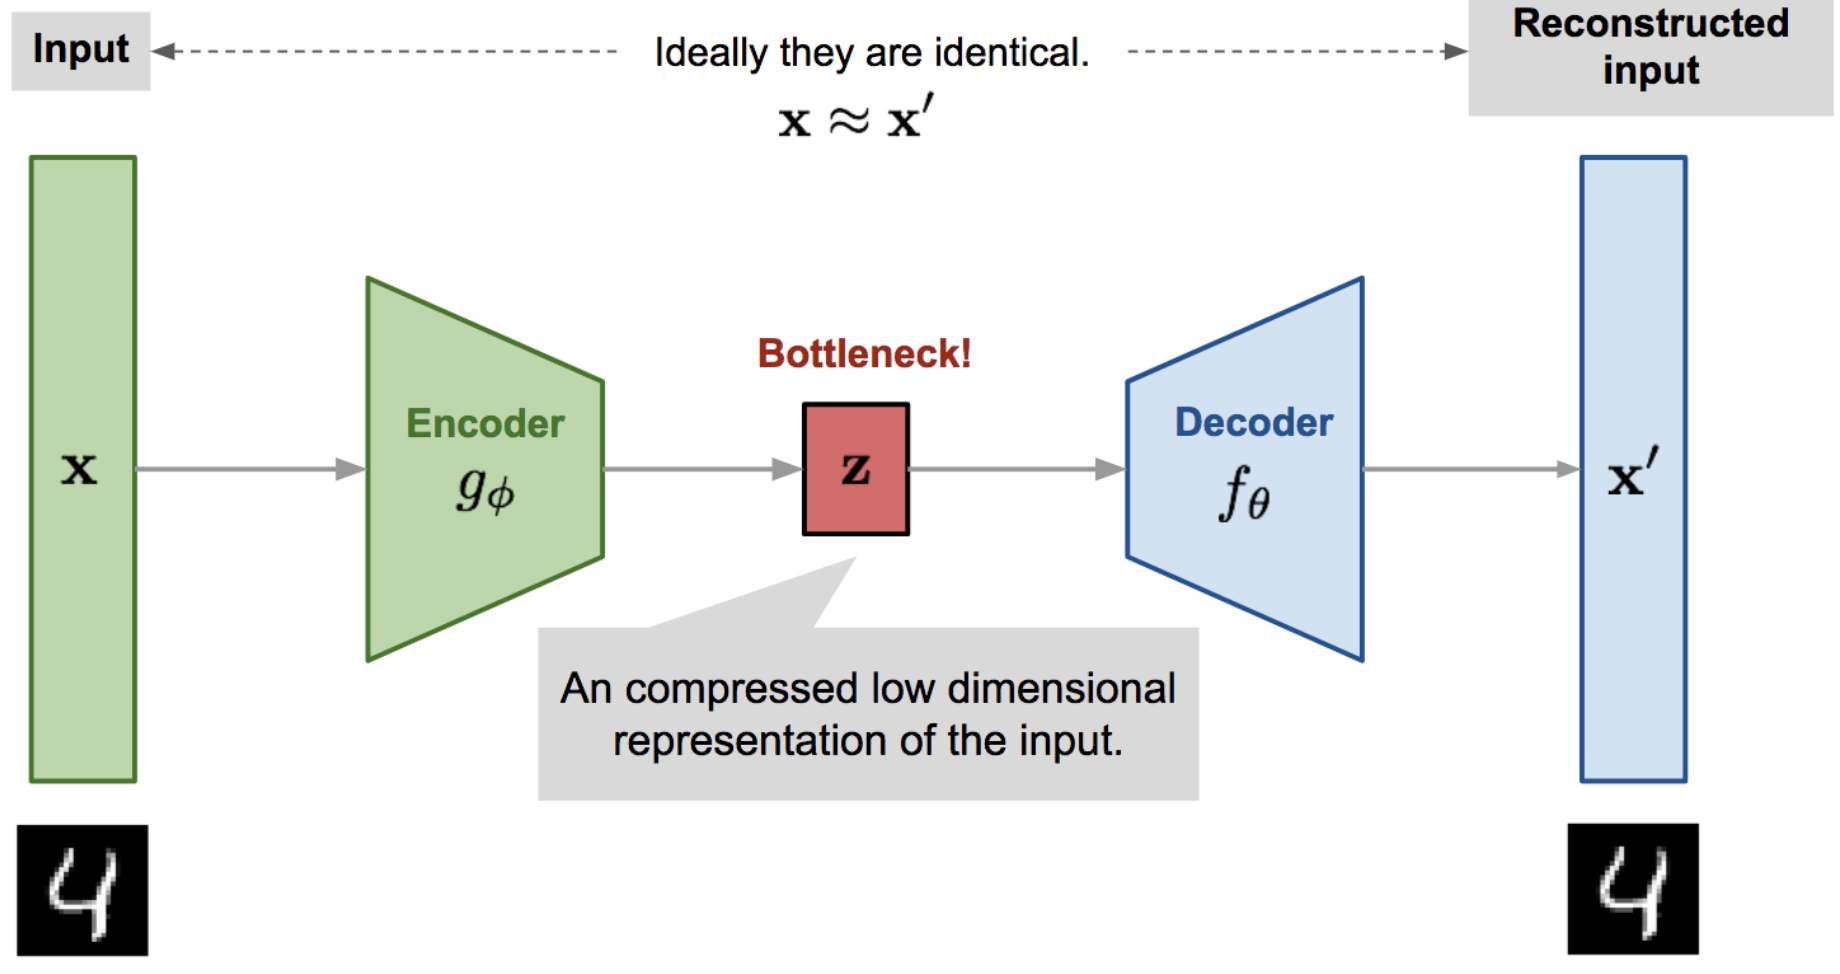

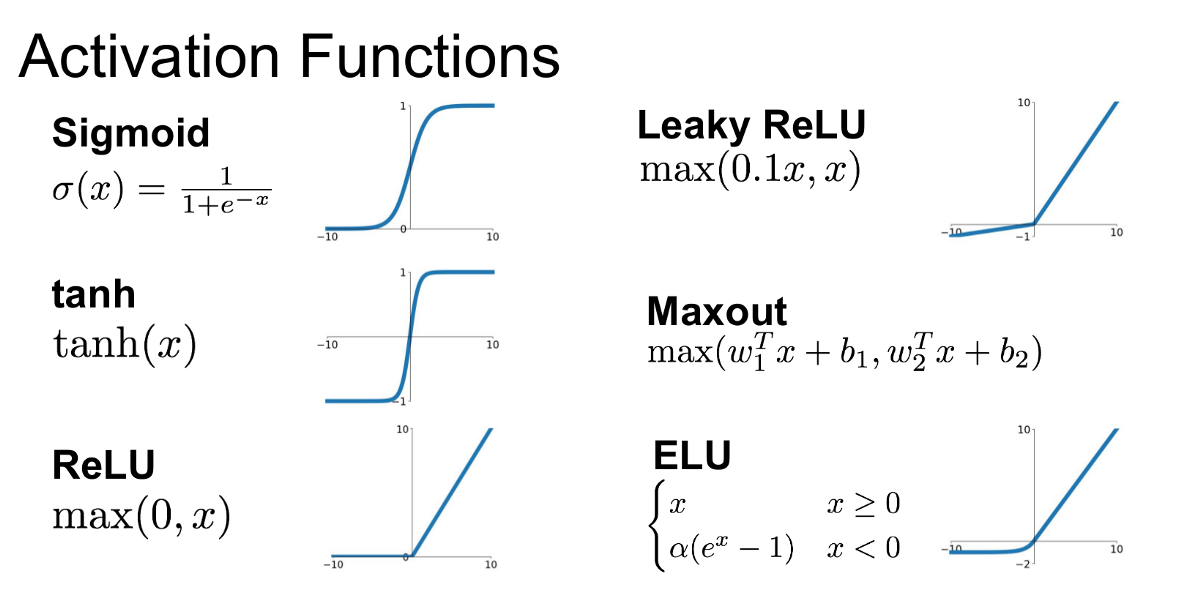




**We introduce channels !! and Convolution....**


In [1]:
class VanillaVAE(nn.Module):
    def __init__(self,
                 in_channels: int = 3,     # Number of input image channels (3 for RGB, 1 for grayscale)
                 latent_dim: int = 128,    # Size of the latent space (bottleneck)
                 hidden_dims: list = None  # List of channel sizes for each conv layer in the encoder/decoder
                ):
        # Initialize the parent class (nn.Module)
        super(VanillaVAE, self).__init__()

        # Store the size of the latent space as an instance variable
        self.latent_dim = latent_dim

        # Define the encoder architecture
        if hidden_dims is None:
            hidden_dims = [32, 64, 128, 256, 512]

        modules = []
        current_in_channels = in_channels



            # Build the convolutional encoder by stacking layers
        for h_dim in hidden_dims:

    # Each layer consists of:
    # 1. Conv2D: with stride=2 to downsample spatial dimensions by half
    # 2. BatchNorm2d: to stabilize and accelerate training....just a normalization ...see Karpathy for more....
    # 3. LeakyReLU: allows small gradients for negative activations (better than ReLU in VAEs)
            modules.append(
                nn.Sequential(
                    nn.Conv2d(in_channels=current_in_channels,     # number of input channels
                              out_channels=h_dim,                  # number of output channels (from hidden_dims list)
                              kernel_size=3,                       # 3x3 convolutional kernel
                              stride=2,                            # downsample by a factor of 2
                              padding=1),                          # keep output size nicely divisible
                    nn.BatchNorm2d(h_dim),                         # normalize activations per-channel
                    nn.LeakyReLU()                                 # non-linearity to allow learning complex mappings
                )
          )

    # Update the number of input channels for the next layer
            current_in_channels = h_dim



        # Wrap all the convolutional blocks into a single Sequential model
        self.encoder = nn.Sequential(*modules)

# After the convolutional layers, the spatial dimensions have been reduced.
# For a 64x64 input and 5 stride-2 layers, the final feature map is typically 2x2.
# With hidden_dims[-1] = 512 (last conv layer output channels), we get 512 * 2 * 2 = 2048 features.
# In this architecture, it assumes that the flattened feature map has size hidden_dims[-1] * 2 * 2 = 2048


# Fully connected layer to produce the mean vector (μ) of the latent distribution
        self.fc_mu = nn.Linear(hidden_dims[-1] * 4, latent_dim)

# Fully connected layer to produce the log-variance vector (log σ²) of the latent distribution
        self.fc_var = nn.Linear(hidden_dims[-1] * 4, latent_dim)



        # Define the decoder architecture
# First, we need to "expand" the latent vector back into a shape that can be fed into the ConvTranspose layers.
# So we map the latent vector (size = latent_dim) to a larger dimensional space matching the encoder's output shape.

        self.decoder_input = nn.Linear(latent_dim, hidden_dims[-1] * 4)

# This will later be reshaped into a 4D tensor suitable for upsampling (e.g., [batch_size, channels, 1, 4])

# Reverse the list of hidden dimensions to mirror the encoder (decoder goes from deep to shallow)
        hidden_dims.reverse()

# Initialize a new list to hold the decoder’s upsampling blocks
        modules = []


        # Build the decoder as a mirror of the encoder using transposed convolutional layers.
    # These layers perform upsampling (i.e., increase the spatial resolution).

        for i in range(len(hidden_dims) - 1):
            modules.append(
                nn.Sequential(
            # Transposed Convolution (also called deconvolution):
            # Upsamples the feature map by a factor of 2 (due to stride=2)
                    nn.ConvTranspose2d(in_channels=hidden_dims[i],     # input channels (start from deepest)
                                       out_channels=hidden_dims[i+1],  # output channels (going toward input shape)
                                       kernel_size=3,                  # 3x3 kernel
                                       stride=2,                       # double spatial resolution
                                       padding=1,                      # standard padding
                                       output_padding=1                # ensures exact output shape after upsampling
                                       ),

            # Normalize the feature maps to improve stability and speed
                    nn.BatchNorm2d(hidden_dims[i+1]),

            # Leaky ReLU: allows small negative gradients (helps with stability in generative models)
                    nn.LeakyReLU()
                )
            )



        # Combine all the upsampling blocks into a single sequential decoder model
        self.decoder = nn.Sequential(*modules)




        # Final layer to map the upsampled feature map back to an image
        self.final_layer = nn.Sequential(

            # Transposed convolution to produce the final image
            nn.ConvTranspose2d(in_channels=hidden_dims[-1],  # Last decoder layer's output channels
                               out_channels=in_channels,     # Match the original image's number of channels (e.g., 3 for RGB)
                               kernel_size=3,                # Standard 3x3 kernel
                               stride=2,                     # Upsample spatial dimensions one last time
                               padding=1,
                               output_padding=1              # Ensures exact spatial alignment
                               ),

    # Output activation:
    # - Use Tanh if your input images were scaled to [-1, 1]
    # - Use Sigmoid if your input images were scaled to [0, 1]
            nn.Tanh()
        )


    def encode(self, input: torch.Tensor) -> list[torch.Tensor]:

        result = self.encoder(input)
        result = torch.flatten(result, start_dim=1)
        mu = self.fc_mu(result)
        log_var = self.fc_var(result)
        return [mu, log_var]

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        result = self.decoder_input(z)
        result = result.view(-1, 512, 2, 2)
        result = self.decoder(result)
        result = self.final_layer(result)
        return result

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return eps * std + mu

    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        recons = self.decode(z)
        return recons, mu, log_var

    def loss_function(self, *args, **kwargs):
        # Unpack args
        recons, input, mu, log_var = args
        kld_weight = kwargs['M_N']
        recons_loss = F.mse_loss(recons, input)
        kld_loss = torch.mean(
            -0.5 * torch.sum(1 + log_var - mu ** 2 - log_var.exp(), dim=1), dim=0
        )
        loss = recons_loss + kld_weight * kld_loss
        return {
            'loss': loss,
            'Reconstruction_Loss': recons_loss.detach(),
            'KLD': -kld_loss.detach()
        }

    def sample(self, num_samples, current_device, **kwargs):
        z = torch.randn(num_samples, self.latent_dim).to(current_device)
        return self.decode(z)

    def generate(self, x: torch.Tensor, **kwargs):
        return self.forward(x)[0]




NameError: name 'nn' is not defined

In [ ]:
# Instantiate the model
vae = VanillaVAE(latent_dim=128, in_channels=3)  # or other config

# Count total and trainable parameters
total_params = sum(p.numel() for p in vae.parameters())
trainable_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print(f"🔢 Total parameters: {total_params:,}")
print(f"🎯 Trainable parameters: {trainable_params:,}")


In [ ]:
from torchsummary import summary

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae.to(device)

# Assuming input image size is 64x64 RGB
summary(vae, input_size=(3, 64, 64))


In [ ]:
import os

# too big for google drive...oltre 250000 immagini  !!

#folder_path = os.path.expanduser("~/Workspace/VAE_Celeba/Data/celeba_raw/img_align_celeba")

#small version, not for training

folder_path = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/img_align_celeba_small")



num_files = len([
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f)) and f.endswith(".jpg")
])

print(f"Number of .jpg files in folder: {num_files}")


In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

# ✅ Local path to CelebA images (after cleanup)
#celeba_root = os.path.expanduser("~/Workspace/VAE_Celeba/Data/celeba_raw/img_align_celeba")
#celeba_root = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/CELEBA/img_align_celeba")
#small version NOT for training
celeba_root = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/DataSet/img_align_celeba_small")

# 🌀 Define image preprocessing
# - Resize to 64x64 (as required by your model)
# - Convert to PyTorch tensor
# - Normalize to [-1, 1] for Tanh decoder compatibility
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5] * 3, std=[0.5] * 3)
])

# 📂 Custom dataset to load images from a flat folder
class CelebADataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_files = [f for f in os.listdir(root_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

# 📦 Create dataset instance
celeba_dataset = CelebADataset(celeba_root, transform=transform)

# 🔄 DataLoader to feed batches to your model
celeba_loader = DataLoader(
    celeba_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=4,      # or 0 if using Windows (not WSL2)
    pin_memory=True
)

# 🧪 Test one batch
images = next(iter(celeba_loader))
print("Loaded batch shape:", images.shape)  # Expect: [128, 3, 64, 64]


In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# Show a grid of 16 images
plt.figure(figsize=(6,6))
plt.axis("off")
plt.title("Sample CelebA Images (normalized)")
plt.imshow(vutils.make_grid(images[:16], nrow=4, normalize=True).permute(1, 2, 0))
plt.show()


In [ ]:
import torch
import torch.optim as optim
from tqdm import tqdm


# ✅ Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instantiate your VAE model and move to GPU if available
latent_dim = 128
model = VanillaVAE(latent_dim=latent_dim).to(device)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optional: total number of samples (used for KL scaling)
dataset_size = len(celeba_loader.dataset)

# Number of epochs
epochs = 20

# 🔁 Training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    total_recons = 0.0
    total_kld = 0.0

    progress = tqdm(celeba_loader, desc=f"Epoch {epoch+1}/{epochs}")


    for batch in progress:
        images= batch
        images = images.to(device)

        optimizer.zero_grad()

        # Forward pass
        recons, mu, logvar = model(images)

        # Compute loss
        loss_dict = model.loss_function(recons, images, mu, logvar, M_N=images.size(0)/dataset_size)
        loss = loss_dict['loss']

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        total_loss += loss.item()
        total_recons += loss_dict['Reconstruction_Loss'].item()
        total_kld += loss_dict['KLD'].item()

        # Update progress bar
        progress.set_postfix({
            'Loss': f"{loss.item():.2f}",
            'Recons': f"{loss_dict['Reconstruction_Loss'].item():.2f}",
            'KLD': f"{loss_dict['KLD'].item():.2f}"
        })

    # 📋 Epoch summary
    avg_loss = total_loss / len(celeba_loader)
    print(f"\n✅ Epoch {epoch+1} complete — Avg Loss: {avg_loss:.4f}")


In [ ]:
import os
import datetime
from pathlib import Path

# Get current date & time
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M")

# Construct smart filename
model_name = f"VanillaVAE_latent{latent_dim}_epoch{epoch+1}_{timestamp}.pt"

# Expand and create target path
#mirko: my local path, adapt if you want to train!!!

save_dir = os.path.expanduser("~/Workspace/VAE_Celeba/Data")
Path(save_dir).mkdir(parents=True, exist_ok=True)

# Full file path
save_path = os.path.join(save_dir, model_name)

# Save the model state_dict
torch.save(model.state_dict(), save_path)

print(f"✅ Model saved as: {save_path}")


In [ ]:
import os
import datetime
from pathlib import Path

# Construct smart filename
#model_name = "VanillaVAE_latent128_epoch1_2025-03-24_19-04.pt"
#model_name="VanillaVAE_latent128_epoch20_2025-03-24_19-26.pt"
model_name="VanillaVAE_latent128_epoch50_2025-03-24_19-50.pt"

# Expand and create target path
save_dir = os.path.expanduser("/content/drive/MyDrive/Colab Notebooks/Models_24_25/Models/")
Path(save_dir).mkdir(parents=True, exist_ok=True)

# Full file path
save_path = os.path.join(save_dir, model_name)



In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the model with correct latent_dim
latent_dim = 128  # make sure this matches training!
model = VanillaVAE(latent_dim=latent_dim)

# Load weights
import os

model_path =save_path
model.load_state_dict(torch.load(model_path, map_location=device))



# Set model to eval mode and move to device

model.to(device)
model.eval()


In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
from tqdm import tqdm


model.eval()  # Ensure we're in inference mode

# 🔮 Sample 16 latent vectors from standard normal distribution
with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decode(z)

# 🖼️ Plot as a grid
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Generated Samples from Latent Space")
plt.imshow(vutils.make_grid(samples, nrow=4, normalize=True).cpu().permute(1, 2, 0))
plt.show()


In [ ]:
# N.B.: for this you need the dataloader of Celeba......or the small one

import torch
import matplotlib.pyplot as plt
import torchvision.utils as vutils

# 🔁 Get a batch and select two faces

images = next(iter(celeba_loader)).to(device)
img1, img2 = images[0].unsqueeze(0), images[1].unsqueeze(0)

# 🔍 Encode to get their latent means
with torch.no_grad():
    mu1, _ = model.encode(img1)
    mu2, _ = model.encode(img2)

# 🔀 Linearly interpolate between mu1 and mu2
num_interp = 8
alphas = torch.linspace(0, 1, steps=num_interp).unsqueeze(1).to(device)
z_interp = mu1 * (1 - alphas) + mu2 * alphas

# 🎨 Decode interpolated latent vectors
with torch.no_grad():
    interpolated_images = model.decode(z_interp)

# 🖼️ Visualize
plt.figure(figsize=(12, 2))
plt.axis("off")
plt.title("Latent Space Interpolation")
plt.imshow(vutils.make_grid(interpolated_images.cpu(), nrow=num_interp, normalize=True).permute(1, 2, 0))
plt.show()


Possible Exercise: Explore Latent Space and non Linear Interpolation

Next Lectur: VQ-VAE

Neural Discrete Representation Learning

https://arxiv.org/abs/1711.00937